(Analyse, Visualise & Report)

In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prevek18/ames-housing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
Path to dataset files: /kaggle/input/ames-housing-dataset


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

try:

    df = pd.read_csv('/content/drive/MyDrive/ames_cleaned.csv')
    print(" Data loaded successfully!")

    df['House_Age'] = df['Yr Sold'] - df['Year Built']
    df['Total_SF'] = df['1st Flr SF'] + df['2nd Flr SF'] + df['Total Bsmt SF']

    print(" Feature engineering completed: 'House_Age' and 'Total_SF' created.")

except FileNotFoundError:
    print(" Error: File 'ames_cleaned.csv' not found in Drive.")
    print("Please ensure the file is uploaded to your MyDrive folder with the correct name.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Data loaded successfully!
 Feature engineering completed: 'House_Age' and 'Total_SF' created.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ames_cleaned.csv')

df['House_Age'] = df['Yr Sold'] - df['Year Built']
df['Total_SF'] = df['1st Flr SF'] + df['2nd Flr SF'] + df['Total Bsmt SF']

def safe_div(num, den):
    return num / den if den != 0 else 0

df['Avg_Room_Size'] = df.apply(lambda row: safe_div(row['Gr Liv Area'], row['TotRms AbvGrd']), axis=1)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(EDA)

In [30]:
sns.set(style="whitegrid")

 (Top 10 Correlation Heatmap)


Analysis: This heatmap displays the Top 10 features most strongly correlated with SalePrice. We can see that Overall Qual and Gr Liv Area have the highest positive impact, while features like Total_SF also show a significant relationship. This helps us focus on the most important variables for price prediction.

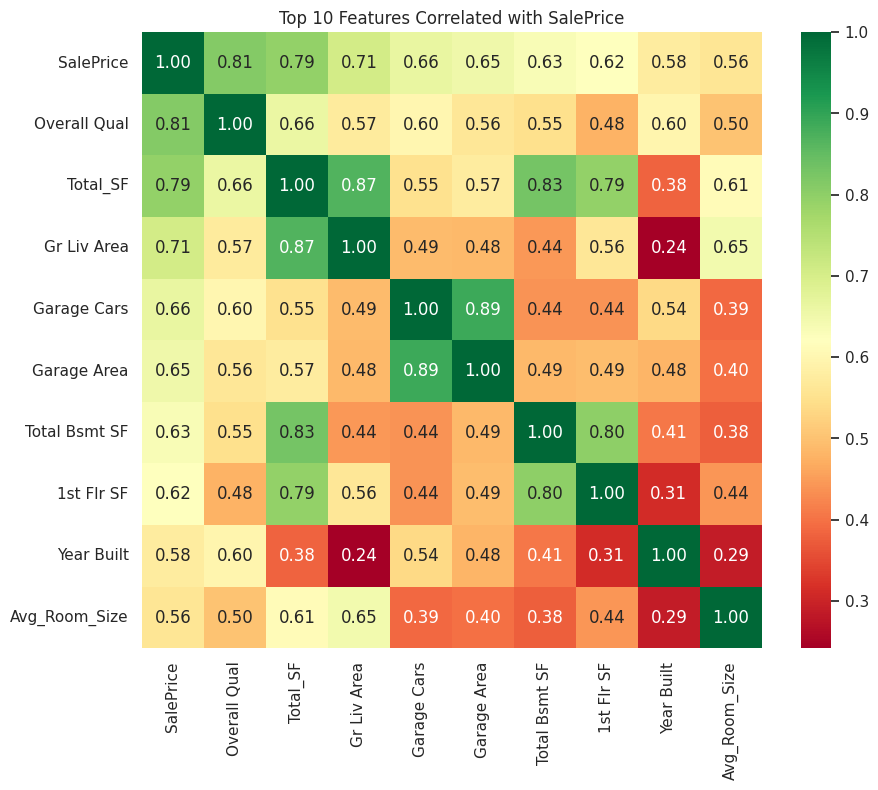

In [40]:
plt.figure(figsize=(10, 8))
top_10_corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(10).index
sns.heatmap(df[top_10_corr].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Top 10 Features Correlated with SalePrice')
plt.show()


(Histograms)

Analysis: These histograms show the distribution of SalePrice, Total_SF, and Gr Liv Area. Most houses are concentrated in the mid-range for all three variables, with a "Right-Skewed" distribution in prices, indicating a few high-end luxury outliers in the dataset.

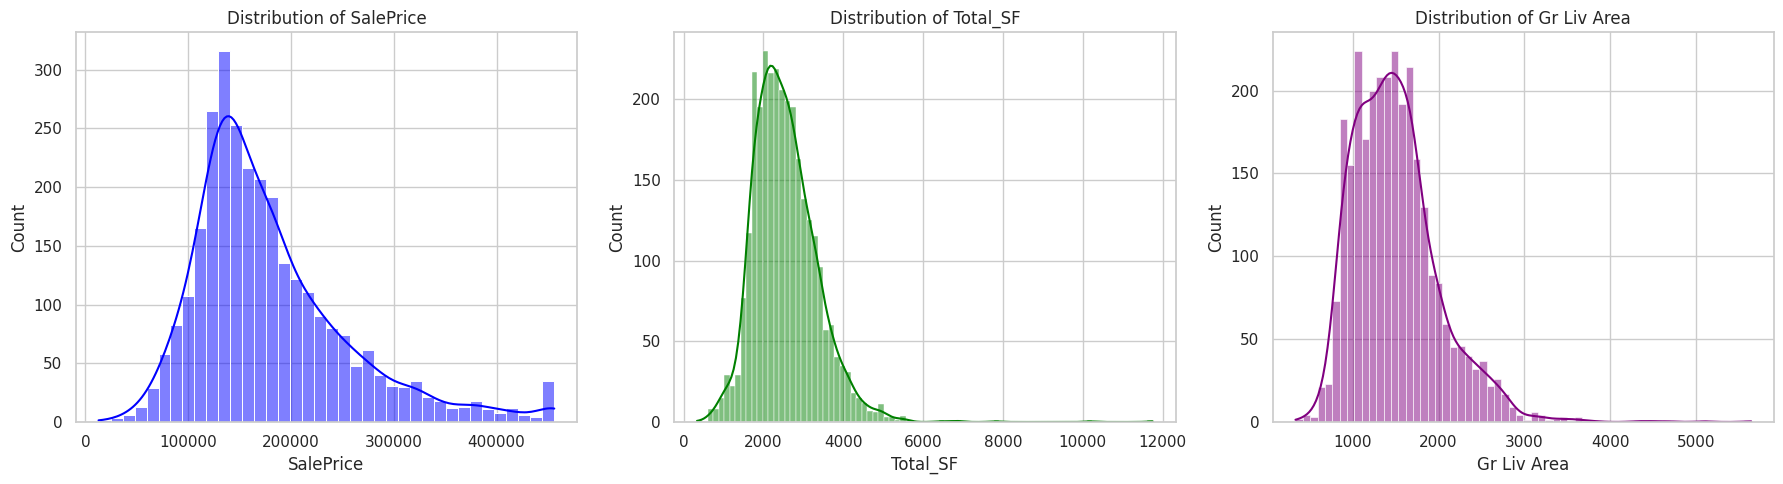

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of SalePrice')

sns.histplot(df['Total_SF'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Total_SF')

sns.histplot(df['Gr Liv Area'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('Distribution of Gr Liv Area')

plt.tight_layout()
plt.show()

 (Box Plot)

Analysis: By comparing SalePrice across Overall Quality and Central Air, we observe that quality is a major price driver. Additionally, houses with central air conditioning command a much higher median price, proving that modern amenities significantly increase property value.

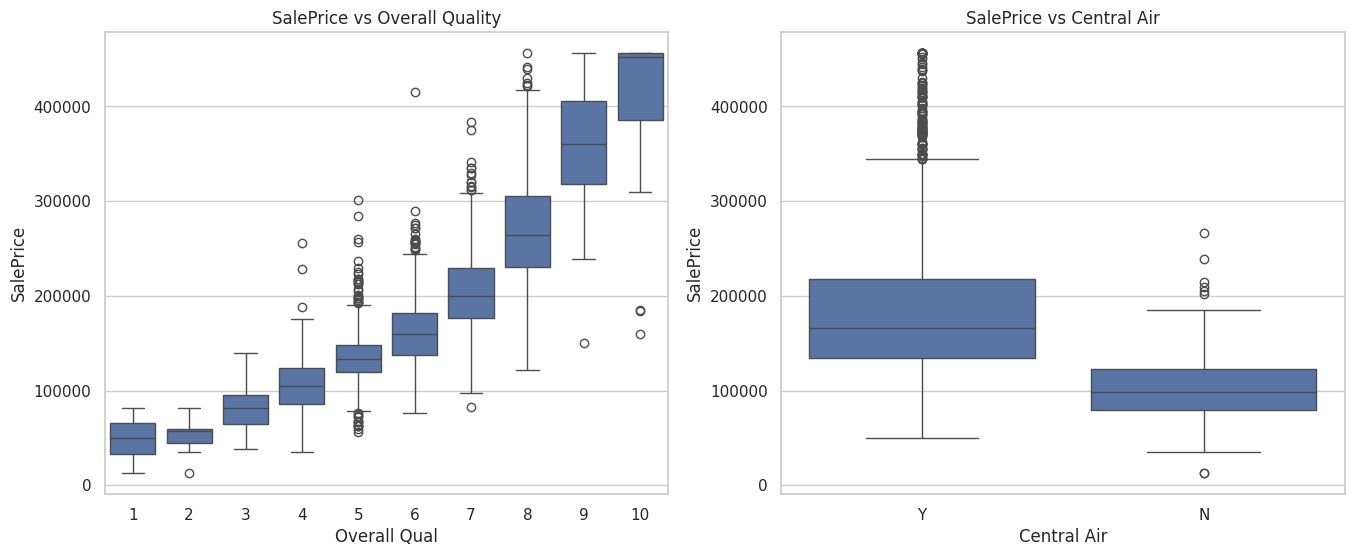

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Overall Qual', y='SalePrice', ax=axes[0])
axes[0].set_title('SalePrice vs Overall Quality')

sns.boxplot(data=df, x='Central Air', y='SalePrice', ax=axes[1])
axes[1].set_title('SalePrice vs Central Air')

plt.show()

(Scatter Plot with Hue)

Analysis: This scatter plot shows the relationship between Total_SF and SalePrice, with Overall Quality as a third dimension (color). It’s clear that even for the same house size, a higher quality rating (darker colors) leads to a much higher sale price.

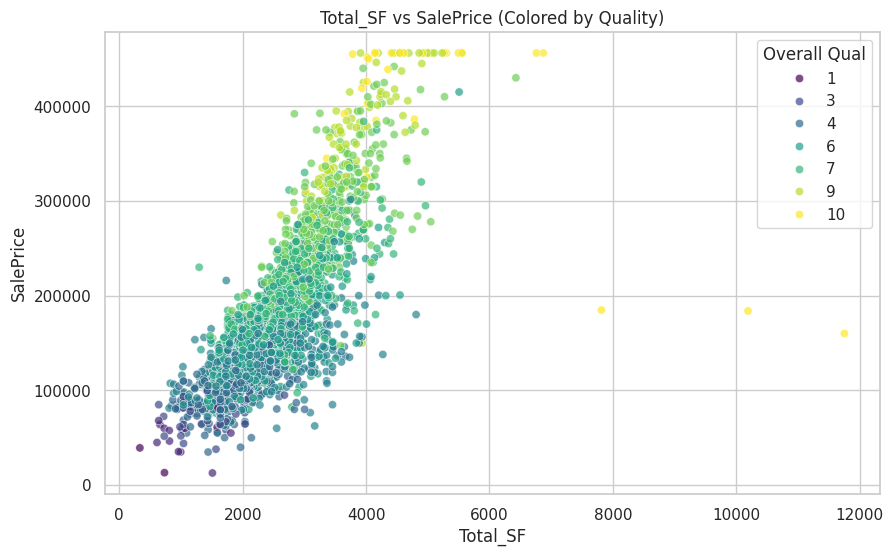

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_SF', y='SalePrice', hue='Overall Qual', palette='viridis', alpha=0.7)
plt.title('Total_SF vs SalePrice (Colored by Quality)')
plt.show()

(Group By Analysis)

Analysis: The Group By summary calculates the average price for each quality level. The bar chart confirms a consistent upward trend, where each increase in quality grade results in a substantial jump in the average market value of the home.

/tmp/ipykernel_21283/2273691209.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=quality_analysis, x='Overall Qual', y='SalePrice', palette='Blues')


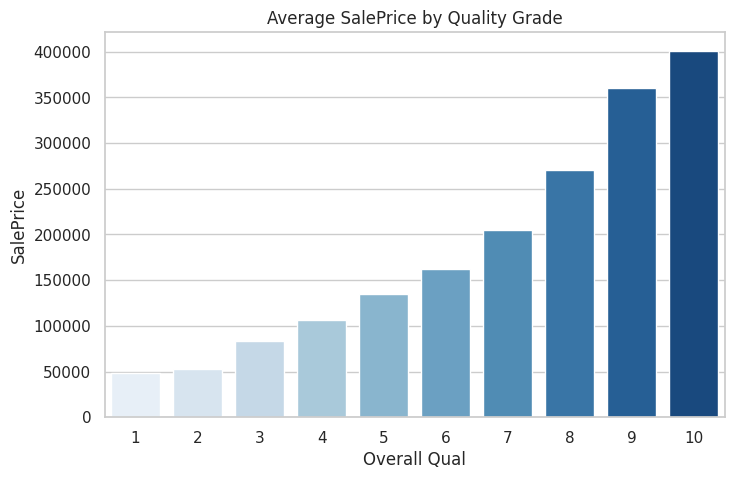

In [44]:
quality_analysis = df.groupby('Overall Qual')[['SalePrice', 'Total_SF']].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=quality_analysis, x='Overall Qual', y='SalePrice', palette='Blues')
plt.title('Average SalePrice by Quality Grade')
plt.show()

Conclusion:
Through this comprehensive analysis, we found that Quality, Total Space, and Modern Amenities are the primary factors determining house prices in Ames. Feature engineering, specifically creating the Total_SF and House_Age variables, provided deeper insights into property valuation.